# <span style='color: pink'>**Advance Coding Project - Madrid Air Quality**</span>
### **Group "Future data scientists"**
Giulia Castelli (300691), Anna Granzotto (300051), Maria Maggiora (297281)

### **Import packages**

In [1]:
import pandas as pd
import numpy as np
import fsspec
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

/Users/giuli/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### **Load Data**

In [ ]:
# Option A: sample CSV for development (default)
df_original = pd.read_csv("data/sample_dataset.csv")

# Option B: full dataset from HuggingFace (uncomment when ready)
# files = fsspec.open_files(
#     "hf://datasets/dmariaa70/METRAQ-Air-Quality/**/*.csv",
#     expand=True
# )
# df_original = pd.concat(
#     [pd.read_csv(f.open()) for f in files],
#     ignore_index=True
# )

## **Task 1 — Load Data and Inspect Structure**

### **1) Exploratory data analysis (EDA)**

We begin our analysis with Exploratory Data Analysis (EDA), a critical first step in understanding the dataset. This process helps reveal the structure of the data, identify unusual values, and uncover patterns using visual tools like graphs and charts. It also plays a key role in ensuring the data is clean and reliable for further analysis. 

#### 1.1) Data Overview and Initial Inspection 

We inspect the raw structure of the dataset: column names, data types, and a preview of the first rows. This confirms the schema matches the documentation and that columns were loaded with the correct types.

In [3]:
df_original = pd.read_csv("data/sample_dataset.csv")

We create a copy of df_original and work on df throughout the analysis, so the raw data is always available for reference.

In [4]:
df = df_original.copy() 
df.head()

,sensor_id,sensor_name,utm_x,utm_y,magnitude_id,magnitude_name,entry_date,value,is_interpolated
0,28079008,Escuelas Aguirre,442117.2366,4474770.696,12,NOX,2006-08-16 01:00:00,56.000000,False
1,28079039,Barrio del Pilar,439689.0496,4481081.619,88,RS,2024-03-21 05:00:00,1.045836,True
2,28079057,Sanchinarro,444026.8080,4482820.581,1023,OC_IDW,2020-03-13 00:00:00,0.000000,False
3,28079049,Parque del Retiro,442095.5200,4473981.740,89,PRECIPITACION,2021-01-30 04:00:00,0.000000,True
4,28079060,Tres Olivos,441556.7005,4483543.994,1023,OC_IDW,2023-12-19 09:00:00,15.933061,False


We analyze the data dimensions using .shape. The number of rows reflects the total measurements loaded, and will differ between the sample and the full dataset.

In [5]:
print(f"Number of rows and columns: {df.shape}")

Number of rows and columns: (100000, 9)


We now get the Column names, which is the list of all features in the dataset.

In [6]:
print(df.columns.tolist())

['sensor_id', 'sensor_name', 'utm_x', 'utm_y', 'magnitude_id', 'magnitude_name', 'entry_date', 'value', 'is_interpolated']


We now get Data types, which specifies the type of each column, such as *str* for categorical features, *float64* or *int64* for numerical features and *bool* for boolean variables.

In [7]:
print(df.dtypes)

sensor_id            int64
sensor_name         object
utm_x              float64
utm_y              float64
magnitude_id         int64
magnitude_name      object
entry_date          object
value              float64
is_interpolated       bool
dtype: object


We check for fully missing columns (NaN). Note that `is_interpolated` tracks reconstructed values separately — a value that was originally missing but later filled will appear as non-null here. We will analyse those reconstructed values in detail in section 1.6.
The output displays the number of missing values in each column, allowing us to detect any remaining incomplete data.

In [8]:
missing_table = df.isna().sum().reset_index()
missing_table.columns = ["Column", "Missing Values"]
missing_table

,Column,Missing Values
0,sensor_id,0
1,sensor_name,0
2,utm_x,0
3,utm_y,0
4,magnitude_id,0
5,magnitude_name,0
6,entry_date,0
7,value,0
8,is_interpolated,0


#### 1.2) Dataset Scale

The PDF explicitly describes the dataset as having three categories of data: air quality, meteorology, and traffic. Before going further, we reproduce that breakdown to understand the scale of each category in our loaded data.


In [9]:
# Classify each row by variable type
pollutants = [
    "CO", "NO", "NO2", "NOX", "SO2", "<PM10", "<PM2.5", "O3",
    "TOLUENO", "BENCENO", "ETILBENCENO",
    "HIDROCARBS_TOTALES", "METANO", "HIDROCARBS_NO_METANICOS"
]
weather = ["VV", "DV", "TEMP", "HR", "PRE", "RS", "PRECIPITACION"]
traffic_mask = df["magnitude_name"].str.startswith(("TI_", "SP_", "OC_"), na=False)
traffic_vars = sorted(df.loc[traffic_mask, "magnitude_name"].unique())

def classify_variable(name):
    if name in pollutants:
        return "pollutant"
    elif name in weather:
        return "weather"
    elif name in traffic_vars:
        return "traffic"
    else:
        return "other"

df["variable_type"] = df["magnitude_name"].apply(classify_variable)

# Scale breakdown table
scale_summary = df.groupby("variable_type").size().rename("rows").reset_index()
scale_summary["percentage"] = (scale_summary["rows"] / len(df) * 100).round(2)
display(scale_summary)

,variable_type,rows,percentage
0,pollutant,39369,39.37
1,traffic,47164,47.16
2,weather,13467,13.47


In [10]:
# Dataset summary
print(f"Total rows      : {len(df):,}")
print(f"Unique sensors  : {df['sensor_name'].nunique()}")
print(f"Unique variables: {df['magnitude_name'].nunique()}")
print(f"Start date      : {df['entry_date'].min()}")
print(f"End date        : {df['entry_date'].max()}")

Total rows      : 100,000
Unique sensors  : 24
Unique variables: 36
Start date      : 2001-01-01 10:00:00
End date        : 2024-12-31 20:00:00


The dataset spans over two decades of hourly measurements across multiple sensors. However, the number of active sensors and variables changes significantly over time — not all variables were collected from the beginning. This makes it essential to study time coverage carefully before any analysis.

#### 1.3) Time Coverage

The project documentation explicitly warns that not all variables are available throughout the entire time span. Here we quantify the date range of each variable and visualize sensor activity over time, which is critical for deciding which time window to use in later tasks.

In [11]:
# Date range and span per variable
time_coverage = (
    df.groupby("magnitude_name")["entry_date"]
    .agg(["min", "max"])
    .assign(
        min=lambda x: pd.to_datetime(x["min"]),
        max=lambda x: pd.to_datetime(x["max"]),
        span_years=lambda x: (
            pd.to_datetime(x["max"]) - pd.to_datetime(x["min"])
        ).dt.days / 365
    )
    .sort_values("span_years", ascending=False)
    .round({"span_years": 1})
)
display(time_coverage)

,min,max,span_years
magnitude_name,,,
NO,2001-01-01 14:00:00,2024-12-31 13:00:00,24.0
NO2,2001-01-01 22:00:00,2024-12-31 13:00:00,24.0
O3,2001-01-02 07:00:00,2024-12-30 11:00:00,24.0
NOX,2001-01-01 10:00:00,2024-12-30 03:00:00,24.0
CO,2001-01-04 06:00:00,2024-12-26 12:00:00,24.0
<PM10,2001-01-05 16:00:00,2024-12-26 07:00:00,24.0
SO2,2001-01-02 14:00:00,2024-12-21 23:00:00,24.0
BENCENO,2001-01-08 10:00:00,2024-12-26 10:00:00,24.0
TOLUENO,2001-01-26 12:00:00,2024-12-31 09:00:00,23.9


We visualize sensor activity as a heatmap: each row is a sensor, each column is a year, and green means the sensor was active that year. This immediately shows which sensors have gaps and which are consistently available.

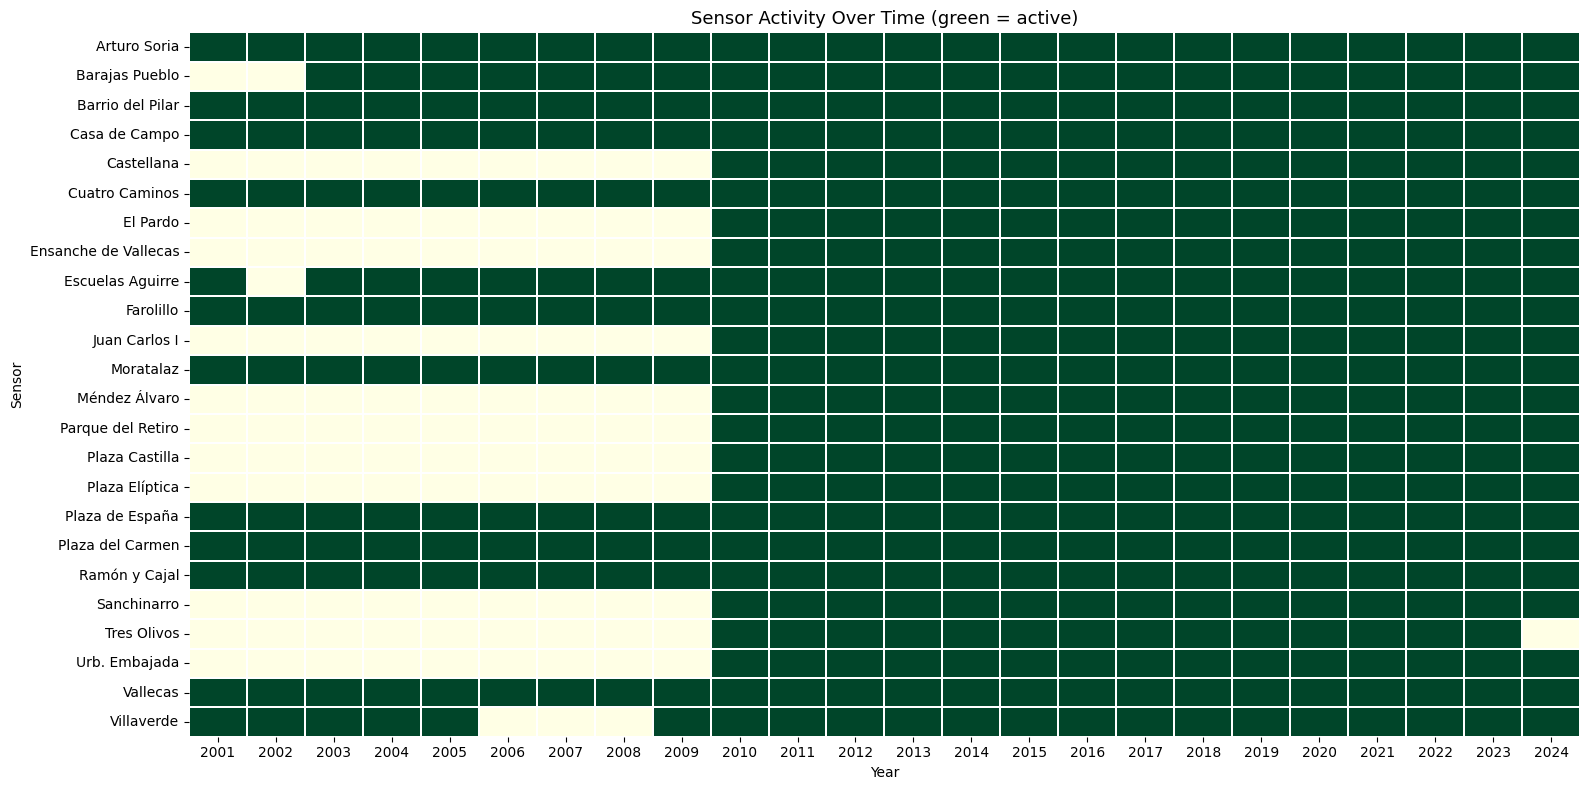

In [12]:
df["year"] = pd.to_datetime(df["entry_date"], errors="coerce").dt.year

availability = (
    df.groupby(["sensor_name", "year"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(availability, cmap="YlGn", linewidths=0.3, ax=ax, cbar=False)
ax.set_title("Sensor Activity Over Time (green = active)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Sensor")
plt.tight_layout()
plt.show()

What we observe — Sensor Activity: The heatmap reveals that sensor coverage is not uniform across time. Some stations have been active since the early 2000s, while others — particularly those measuring traffic variables — only appear in later years. This confirms the project documentation's warning that not all variables are simultaneously available throughout the full time span. For tasks requiring all three categories (pollutants, weather, traffic) to overlap, we should restrict the analysis to the period where all are consistently present, which based on this heatmap appears to be approximately from 2018 onward. This time window decision will be confirmed when building the correlation and forecasting models in later tasks.

#### 1.4) Identification of Pollutants, Weather and Traffic Variables

The dataset contains different types of variables that describe air quality conditions. To make the analysis more structured, we group these variables into three main categories:
- Air pollutant variables
- Meteorological variables
- Traffic variables

In [13]:
df_pollutants = df[df["magnitude_name"].isin(pollutants)].copy()
df_weather    = df[df["magnitude_name"].isin(weather)].copy()
df_traffic    = df[df["magnitude_name"].isin(traffic_vars)].copy()

print(f"Pollutants found : {[p for p in pollutants if p in df['magnitude_name'].values]}")
print(f"Weather found    : {[w for w in weather if w in df['magnitude_name'].values]}")
print(f"Traffic found    : {traffic_vars}")
print()
print(f"Pollutant rows : {len(df_pollutants):,}")
print(f"Weather rows   : {len(df_weather):,}")
print(f"Traffic rows   : {len(df_traffic):,}")

Pollutants found : ['CO', 'NO', 'NO2', 'NOX', 'SO2', '<PM10', '<PM2.5', 'O3', 'TOLUENO', 'BENCENO', 'ETILBENCENO', 'HIDROCARBS_TOTALES', 'METANO', 'HIDROCARBS_NO_METANICOS']
Weather found    : ['VV', 'DV', 'TEMP', 'HR', 'PRE', 'RS', 'PRECIPITACION']
Traffic found    : ['OC_IDW', 'OC_KRIGING', 'OC_RBF_GAUSSIAN', 'OC_RBF_LINEAR', 'OC_RBF_MULTIQUADRIQ', 'SP_IDW', 'SP_KRIGING', 'SP_RBF_GAUSSIAN', 'SP_RBF_LINEAR', 'SP_RBF_MULTIQUADRIQ', 'TI_IDW', 'TI_KRIGING', 'TI_RBF_GAUSSIAN', 'TI_RBF_LINEAR', 'TI_RBF_MULTICUADRIC']

Pollutant rows : 39,369
Weather rows   : 13,467
Traffic rows   : 47,164


For each category, we show which sensors contributed data and over what time range.

In [14]:
pollutant_table = df_pollutants.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"])
display(pollutant_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Casa de Campo,2001-01-01 22:00:00,2024-12-30 11:00:00,4137
Escuelas Aguirre,2001-01-04 02:00:00,2024-12-29 13:00:00,3909
Farolillo,2001-01-03 01:00:00,2024-12-26 07:00:00,2829
Cuatro Caminos,2001-01-10 12:00:00,2024-12-23 04:00:00,2394
Moratalaz,2001-01-08 15:00:00,2024-12-30 07:00:00,1912
Plaza del Carmen,2001-01-07 12:00:00,2024-12-11 19:00:00,1900
Urb. Embajada,2010-01-01 10:00:00,2024-12-31 09:00:00,1841
Ramón y Cajal,2001-01-03 17:00:00,2024-12-30 03:00:00,1678
Plaza de España,2001-01-04 02:00:00,2024-12-04 22:00:00,1667


In [15]:
weather_table = df_weather.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"])
display(weather_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Farolillo,2019-01-07 17:00:00,2024-12-30 03:00:00,600
Villaverde,2019-01-03 23:00:00,2024-12-28 18:00:00,589
Barajas Pueblo,2019-01-03 23:00:00,2024-12-31 11:00:00,589
Vallecas,2019-01-04 07:00:00,2024-12-28 11:00:00,587
Casa de Campo,2019-01-05 07:00:00,2024-12-25 17:00:00,584
Arturo Soria,2019-01-01 13:00:00,2024-12-30 11:00:00,581
Castellana,2019-01-02 01:00:00,2024-12-27 01:00:00,580
Urb. Embajada,2019-01-04 20:00:00,2024-12-27 09:00:00,575
Sanchinarro,2019-01-02 14:00:00,2024-12-31 13:00:00,575


In [16]:
traffic_table = df_traffic.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"])
display(traffic_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Cuatro Caminos,2015-01-01 15:00:00,2024-12-31 16:00:00,2066
Vallecas,2015-01-01 05:00:00,2024-12-26 18:00:00,2043
Moratalaz,2015-01-04 09:00:00,2024-12-31 11:00:00,2039
Farolillo,2015-01-04 04:00:00,2024-12-29 13:00:00,2027
Villaverde,2015-01-04 09:00:00,2024-12-31 17:00:00,2019
Barrio del Pilar,2015-01-03 07:00:00,2024-12-29 15:00:00,2005
El Pardo,2015-01-02 20:00:00,2024-12-29 11:00:00,2003
Casa de Campo,2015-01-01 13:00:00,2024-12-31 20:00:00,1999
Plaza del Carmen,2015-01-03 21:00:00,2024-12-31 15:00:00,1994


The three tables above confirm that pollutant sensors are the most widespread and consistent, while traffic sensors have a shorter operational history and are concentrated in fewer locations. Weather sensors fall in between. This asymmetry will influence which sensors and time periods we can use in multi-variable analyses.

#### 1.5) Descriptive Statistics 

We compute summary statistics (count, mean, median, standard deviation, min, max) grouped by variable type and then individually per pollutant. This gives a first sense of value ranges, spread, and which variables dominate the dataset.

In [17]:
stats_by_type = df.groupby("variable_type")["value"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
display(stats_by_type)

,count,mean,median,std,min,max
variable_type,,,,,,
pollutant,39369,29.311332,11.000000,55.389101,0.0,1819.000000
traffic,47164,109.848495,8.694178,308.762042,0.0,10962.715782
weather,13467,194.226186,25.000000,334.858985,-55.0,1027.680482


In [18]:
pollutant_stats = (
    df[df["variable_type"] == "pollutant"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)
display(pollutant_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
NOX,6403,73.940259,42.0,102.818736,2.0,1819.0
NO,6397,23.955600,6.0,52.998611,0.0,700.0
NO2,6268,38.827508,31.0,29.675459,1.0,270.0
O3,3519,47.454229,46.0,32.195761,0.0,176.0
<PM10,3221,22.483451,17.0,21.449230,1.0,335.0
SO2,2789,8.163065,7.0,7.135345,1.0,129.0
CO,2689,0.069543,0.0,0.345030,0.0,8.0
<PM2.5,1473,10.612057,9.0,8.352564,0.0,60.0
BENCENO,1458,0.283782,0.0,1.001176,0.0,17.0


Descriptive Statistics — Weather and Traffic Variables
We extend the same analysis to meteorological and traffic variables. Since these will be used in later tasks to explain pollution levels, understanding their value ranges now is essential. Note that weather variables use physical units (°C for temperature, % for humidity, etc.) while traffic variables are dimensionless scores reconstructed through spatial interpolation.

In [19]:
weather_stats = (
    df[df["variable_type"] == "weather"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)
display(weather_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
VV,1981,0.803797,0.645087,1.008040,0.0,23.655599
PRE,1965,935.981907,943.384598,58.465443,0.0,1027.680482
RS,1928,200.493329,15.604381,286.783026,0.0,1020.650136
HR,1913,56.401053,55.637280,22.820417,0.0,114.604574
DV,1899,132.243018,120.911977,82.469741,1.0,353.000000
TEMP,1896,15.408320,14.000000,9.224790,-55.0,39.772838
PRECIPITACION,1885,0.030374,0.000000,0.297594,0.0,6.458596


In [20]:
traffic_stats = (
    df[df["variable_type"] == "traffic"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)
display(traffic_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
SP_RBF_LINEAR,3356,18.560957,1.564934e+01,14.521229,0.000000,83.323030
OC_IDW,3310,6.097396,3.979334e+00,7.383894,0.000000,81.319692
SP_RBF_GAUSSIAN,3293,0.003509,4.245719e-77,0.038497,0.000000,0.723518
SP_IDW,3284,17.749242,1.444119e+01,13.614283,0.000000,76.833478
OC_RBF_GAUSSIAN,3283,0.003395,2.093265e-96,0.034449,0.000000,0.747379
SP_RBF_MULTIQUADRIQ,3257,21.470666,1.487765e+01,40.876085,0.000000,1408.000000
SP_KRIGING,3225,17.330345,1.631113e+01,10.020267,2.152613,39.665348
OC_RBF_LINEAR,3224,6.320223,3.612589e+00,8.862534,0.000000,75.160188
OC_KRIGING,3192,6.697200,5.997533e+00,3.567722,0.990189,16.954708


The descriptive statistics highlight important differences across categories. Pollutant concentrations tend to be right-skewed with large standard deviations, reflecting occasional pollution spikes. Weather variables show more stable distributions. Traffic variables exhibit high variability depending on the interpolation method used, which is worth keeping in mind when using them as predictors.

#### 1.6) Missing Values & Data Quality 

Before plotting, we check data quality. The is_interpolated flag tells us which values were originally missing and reconstructed by the dataset authors. We quantify this per variable, and also check for physically impossible values such as negative pollutant concentrations.

In [21]:
total = len(df)
total_interpolated = df["is_interpolated"].sum()
total_original = (~df["is_interpolated"]).sum()

print(f"Total records       : {total:,}")
print(f"Original values     : {total_original:,} ({100*total_original/total:.1f}%)")
print(f"Interpolated values : {total_interpolated:,} ({100*total_interpolated/total:.1f}%)")

Total records       : 100,000
Original values     : 88,842 (88.8%)
Interpolated values : 11,158 (11.2%)


A non-trivial fraction of values in the dataset were reconstructed through interpolation rather than directly measured. This is important to keep in mind: analyses that treat all values equally may be influenced by the interpolation method. In Task 3 we will compare the dataset's interpolation strategy against our own imputation methods.

In [22]:
# Interpolation rate per variable
interp_rate = (
    df.groupby("magnitude_name")["is_interpolated"]
    .agg(["sum", "count"])
    .assign(rate=lambda x: (x["sum"] / x["count"]).round(3))
    .sort_values("rate", ascending=False)
    .rename(columns={"sum": "interpolated", "count": "total"})
)
display(interp_rate)

,interpolated,total,rate
magnitude_name,,,
RS,1706,1928,0.885
PRE,1729,1965,0.880
DV,1584,1899,0.834
VV,1646,1981,0.831
PRECIPITACION,1469,1885,0.779
HR,1095,1913,0.572
TEMP,949,1896,0.501
ETILBENCENO,77,1449,0.053
BENCENO,70,1458,0.048


The interpolation rate varies considerably across variables. Some variables have very few missing values while others were reconstructed for a large fraction of their timeline. Variables with high interpolation rates should be treated with more caution in downstream modelling.

In [23]:
# Physically impossible values: negative concentrations for pollutants
negative_vals = df[(df["variable_type"] == "pollutant") & (df["value"] < 0)]
print(f"Negative pollutant readings: {len(negative_vals)}")
if len(negative_vals) > 0:
    display(negative_vals.groupby("magnitude_name").size().rename("count"))

Negative pollutant readings: 0


Negative concentration values are physically impossible for pollutants and represent measurement or sensor errors. If any are found, they should be treated as invalid and either removed or flagged before further analysis, regardless of whether they were marked as interpolated.

#### 1.7) In-Depth Spatial Analysis 

We rank monitoring stations by relative pollution level. Since each pollutant uses different units (CO in mg/m³, NO2 in µg/m³, etc.), summing raw values directly would be meaningless. We apply z-score normalization within each pollutant first, so every variable contributes equally to the ranking regardless of scale.

In [24]:
df_pollutants["value_norm"] = (
    df_pollutants.groupby("magnitude_name")["value"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

sensor_total_pollution = (
    df_pollutants
    .groupby("sensor_name")["value_norm"]
    .sum()
    .reset_index()
    .rename(columns={"value_norm": "pollution_score"})
    .sort_values("pollution_score", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 most polluted stations:")
display(sensor_total_pollution.head(10))

Top 10 most polluted stations:


,sensor_name,pollution_score
0,Escuelas Aguirre,804.213588
1,Plaza de España,388.462067
2,Cuatro Caminos,293.726672
3,Villaverde,235.393496
4,Plaza del Carmen,221.090303
5,Moratalaz,153.146430
6,Barrio del Pilar,147.965811
7,Ramón y Cajal,147.072909
8,Plaza Elíptica,115.720654
9,Barajas Pueblo,-13.757034


We project sensor locations onto an interactive map of Madrid. Darker red indicates higher relative pollution. Labels highlight the top 10 most affected stations.

In [25]:
# Merge coordinates back (they were lost during groupby)
coords = df_pollutants[["sensor_name", "utm_x", "utm_y"]].drop_duplicates("sensor_name")
sensor_total_pollution = sensor_total_pollution.merge(coords, on="sensor_name", how="left")

gdf = gpd.GeoDataFrame(
    sensor_total_pollution,
    geometry=gpd.points_from_xy(
        sensor_total_pollution["utm_x"],
        sensor_total_pollution["utm_y"]
    ),
    crs="EPSG:25830"
)
gdf_web = gdf.to_crs(epsg=3857)

We now visualize these rankings geographically. The map allows us to check whether the most polluted stations cluster in specific areas of the city — for example near busy roads, industrial zones, or the city centre — or whether pollution is more uniformly distributed.

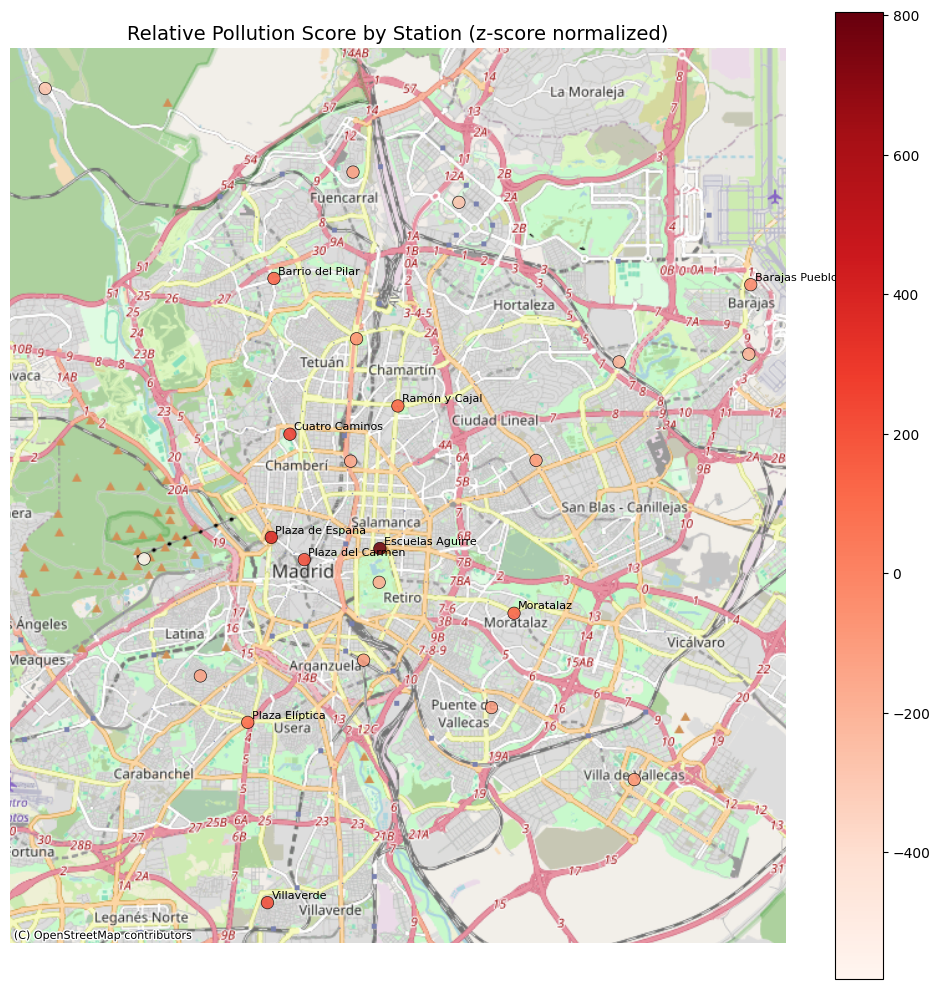

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_web.plot(
    ax=ax,
    column="pollution_score",
    cmap="Reds",
    legend=True,
    markersize=80,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

top10 = gdf_web.nlargest(10, "pollution_score")
for _, row in top10.iterrows():
    ax.annotate(
        text=str(row["sensor_name"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Relative Pollution Score by Station (z-score normalized)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

What we observe — Spatial Distribution: The map shows that pollution is not evenly distributed across Madrid. Stations in the city centre and along major traffic corridors tend to score higher, while peripheral stations show lower pollution scores. This spatial pattern is consistent with traffic being a primary driver of urban air pollution. The most affected stations will be the focus of closer analysis in the temporal and network tasks.

#### 1.8) Time-Series Plots 

We parse entry_date to datetime once and reuse it across all time-series plots.

In [27]:
for _df in [df_pollutants, df_weather, df_traffic]:
    _df["entry_date"] = pd.to_datetime(_df["entry_date"], errors="coerce")

Pollutants — monthly mean per pollutant. We plot each of the 6 most common pollutants separately on its own subplot. Using mean (not sum) keeps the values interpretable as average concentration levels.

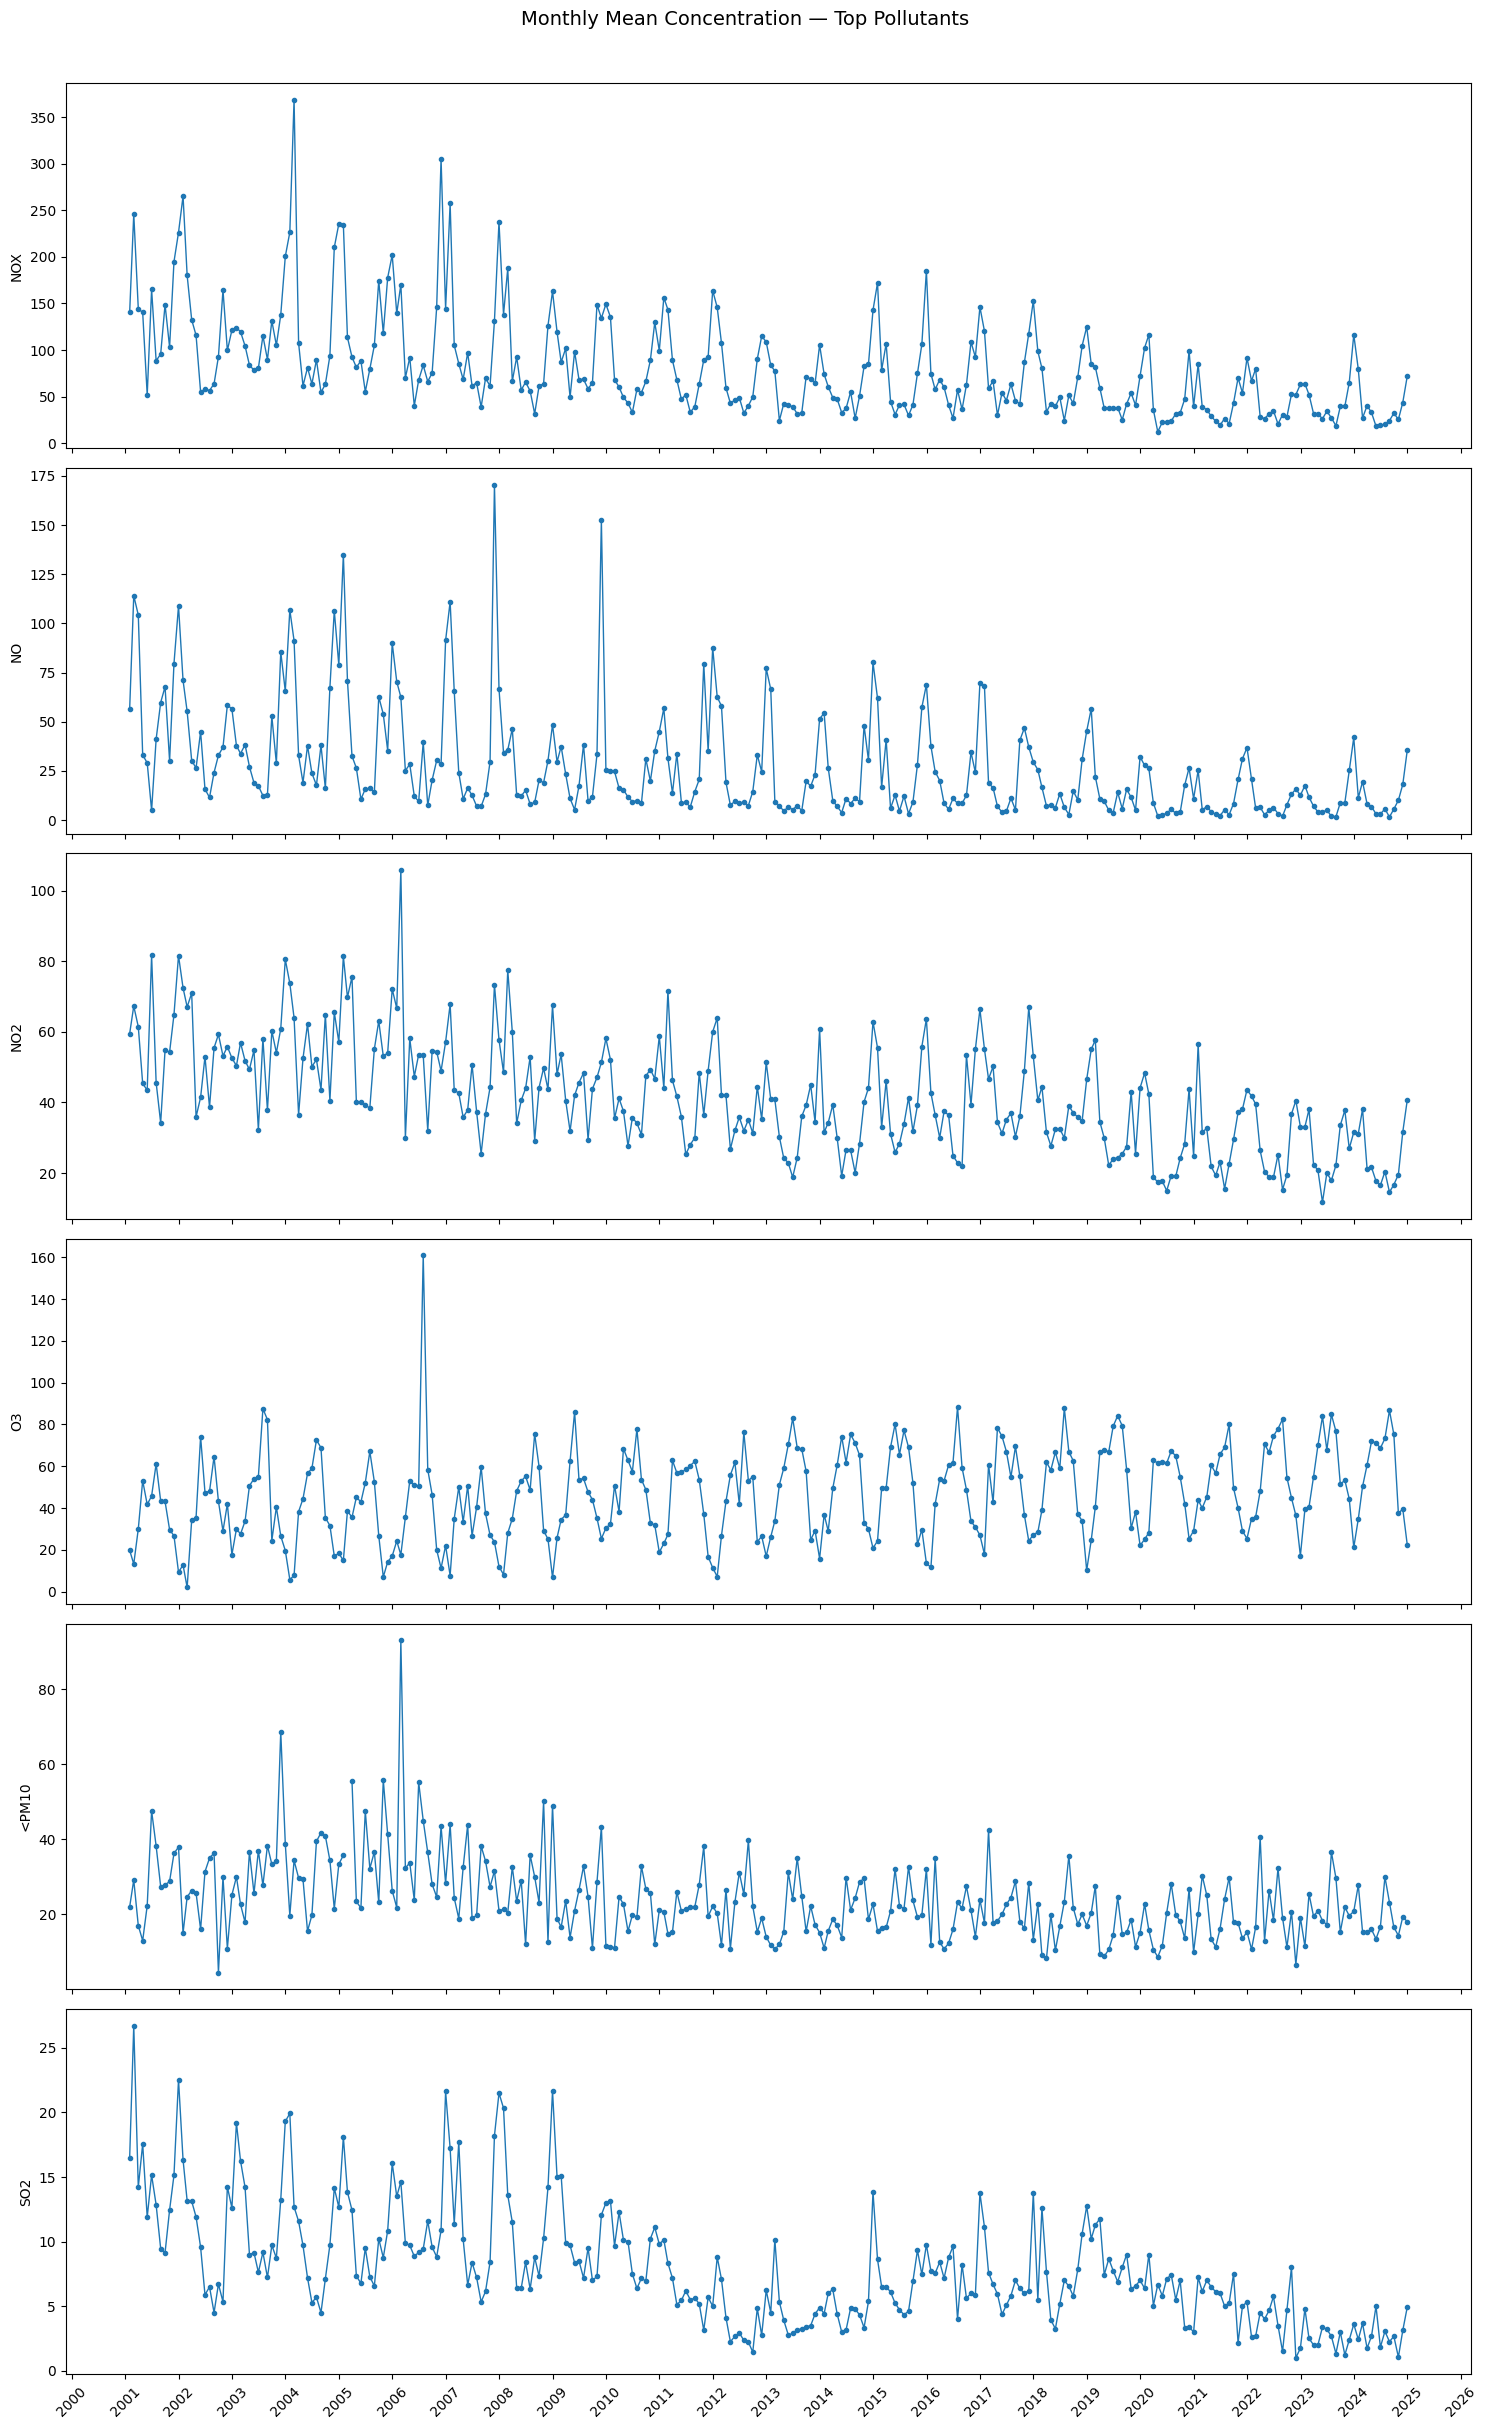

In [28]:
top_pollutants = (
    df_pollutants.groupby("magnitude_name")["value"]
    .count()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(len(top_pollutants), 1,
                          figsize=(15, 4 * len(top_pollutants)), sharex=True)

for ax, pol in zip(axes, top_pollutants):
    subset = (
        df_pollutants[df_pollutants["magnitude_name"] == pol]
        .set_index("entry_date")["value"]
        .resample("ME").mean()
    )
    ax.plot(subset.index, subset.values, marker="o", markersize=3, linewidth=1)
    ax.set_ylabel(pol, fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("Monthly Mean Concentration — Top Pollutants", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

What we observe — Pollutant Time Series: Several pollutants show clear seasonal patterns, with higher concentrations in winter months. This is typical in urban environments: colder temperatures reduce atmospheric mixing, trapping pollutants near the surface. Additionally, lower UV radiation in winter slows the photochemical breakdown of NO2 and NOX. If a long-term downward trend is visible for CO or SO2, this likely reflects improvements in vehicle emission standards and fuel quality over the years. Any sharp drops around 2020 may correspond to the COVID-19 lockdown period, which drastically reduced traffic across Madrid.

Weather — monthly mean per meteorological variable. Each variable has its own unit so we never combine them. We use mean as the aggregation.

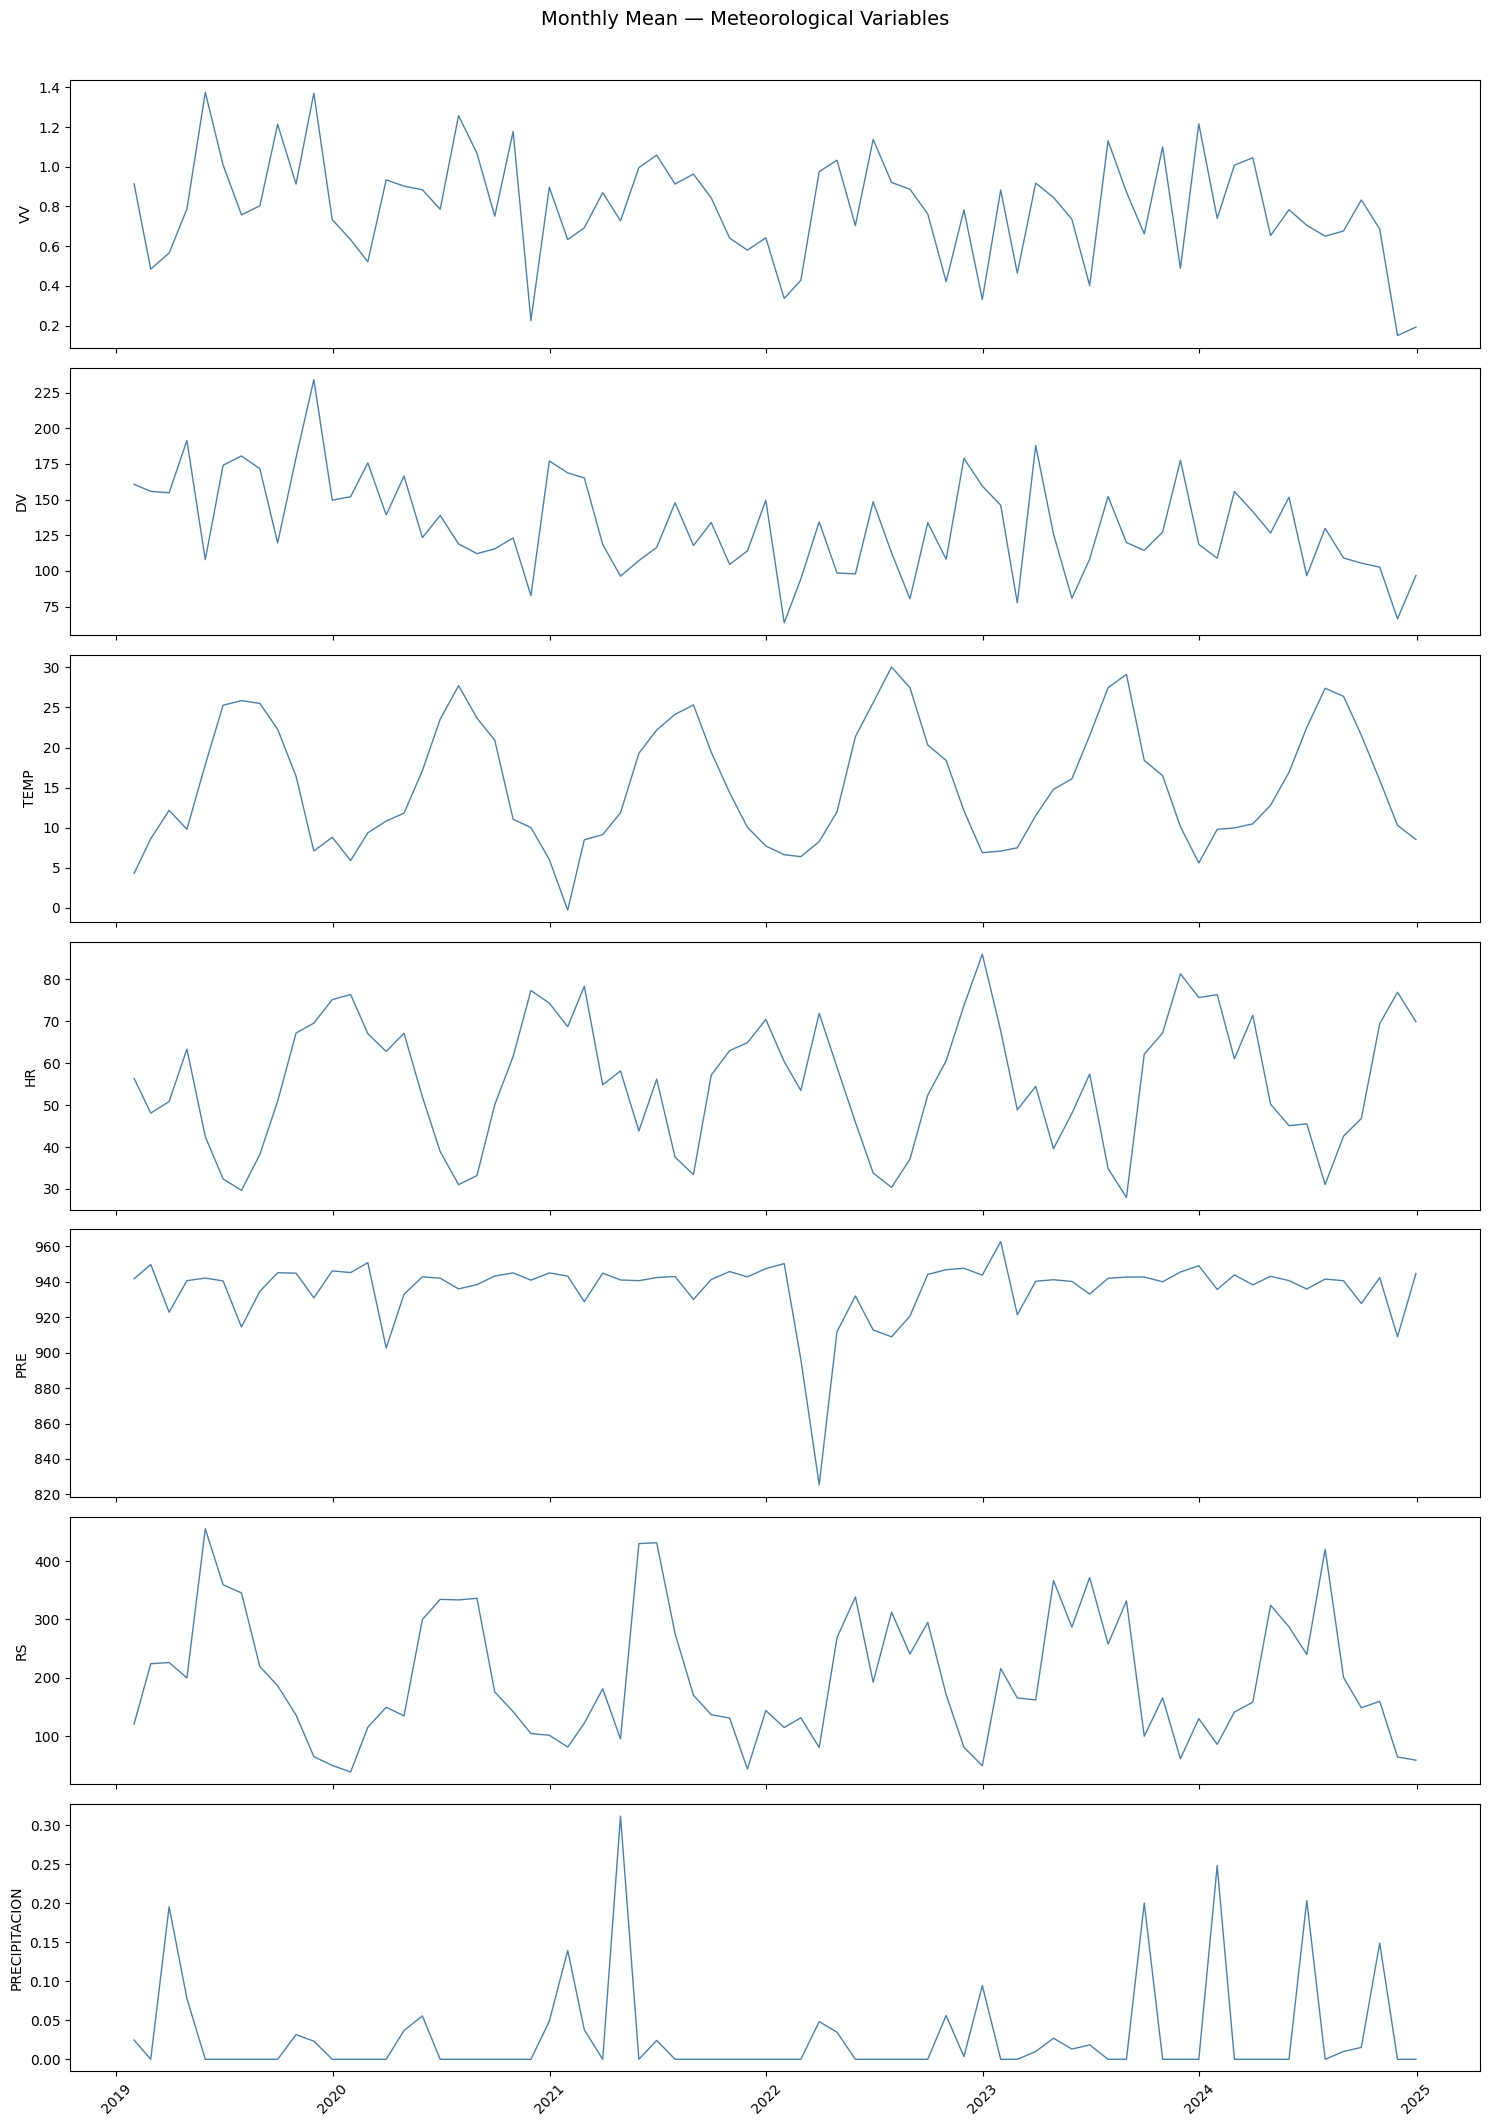

In [29]:
weather_in_data = [w for w in weather if w in df_weather["magnitude_name"].values]

fig, axes = plt.subplots(len(weather_in_data), 1,
                          figsize=(15, 3 * len(weather_in_data)), sharex=True)
if len(weather_in_data) == 1:
    axes = [axes]

for ax, var in zip(axes, weather_in_data):
    subset = (
        df_weather[df_weather["magnitude_name"] == var]
        .set_index("entry_date")["value"]
        .resample("ME").mean()
    )
    ax.plot(subset.index, subset.values, color="steelblue", linewidth=1)
    ax.set_ylabel(var, fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("Monthly Mean — Meteorological Variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

What we observe — Weather Time Series: Temperature (TEMP) shows clear annual cycles as expected, with consistent summer peaks and winter troughs. Solar radiation (RS) follows the same seasonal pattern and will be relevant for understanding O3 formation in later tasks, since ozone is produced through photochemical reactions driven by sunlight. Relative humidity (HR) tends to peak in winter and autumn. Rainfall (PRECIPITACION) is irregular and episodic — wet deposition is known to temporarily reduce PM10 concentrations, which we may observe when cross-referencing the two variables.

Traffic — monthly mean split by type. We separate the three traffic metrics (TI = intensity, SP = speed, OC = occupancy) and average across interpolation methods to reduce noise from the five spatial methods.

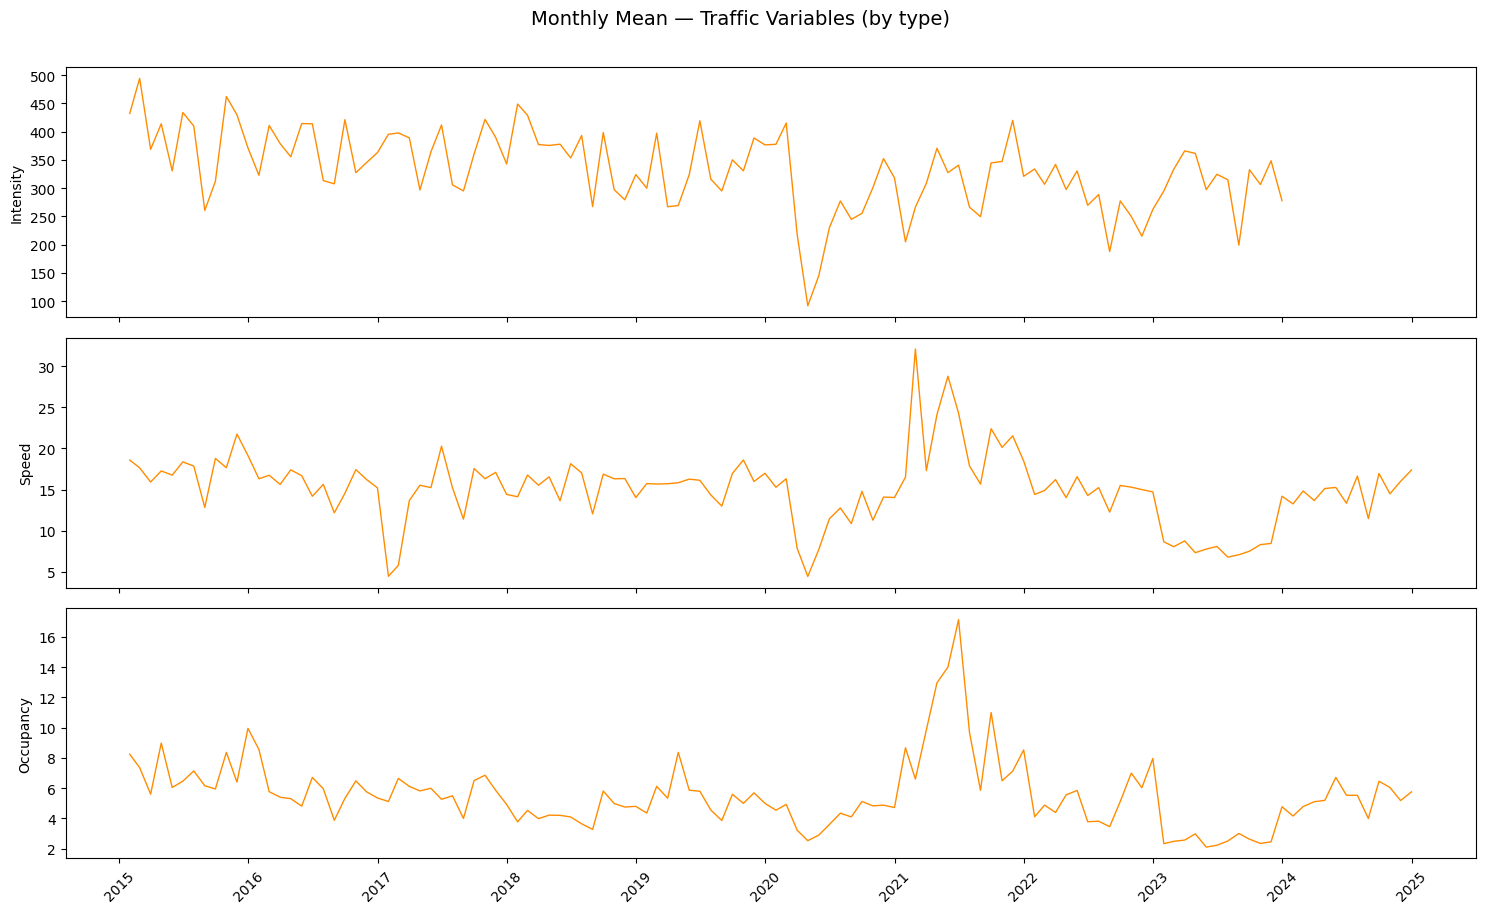

In [30]:
df_traffic["traffic_type"] = df_traffic["magnitude_name"].str[:2]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for ax, (ttype, label) in zip(axes, [("TI", "Intensity"), ("SP", "Speed"), ("OC", "Occupancy")]):
    subset = (
        df_traffic[df_traffic["traffic_type"] == ttype]
        .set_index("entry_date")["value"]
        .resample("ME").mean()
    )
    ax.plot(subset.index, subset.values, color="darkorange", linewidth=1)
    ax.set_ylabel(label, fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("Monthly Mean — Traffic Variables (by type)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

What we observe — Traffic Time Series: Traffic intensity (TI) and occupancy (OC) should move together — higher congestion means more vehicles per road segment. Speed (SP) should move inversely: as roads become more congested, average speed drops. If a sharp drop is visible around 2020, this reflects the COVID-19 lockdowns which nearly halted vehicle traffic in Madrid during spring 2020. Any seasonal dips in August are consistent with the typical summer exodus from the city, when many residents leave for holidays and traffic drops significantly.

#### 1.9) Distribution Plots 

Histograms with KDE show the empirical distribution of each pollutant. Values are clipped at the 99th percentile to prevent extreme outliers from distorting the scale. Right-skewed distributions are common in air quality data.

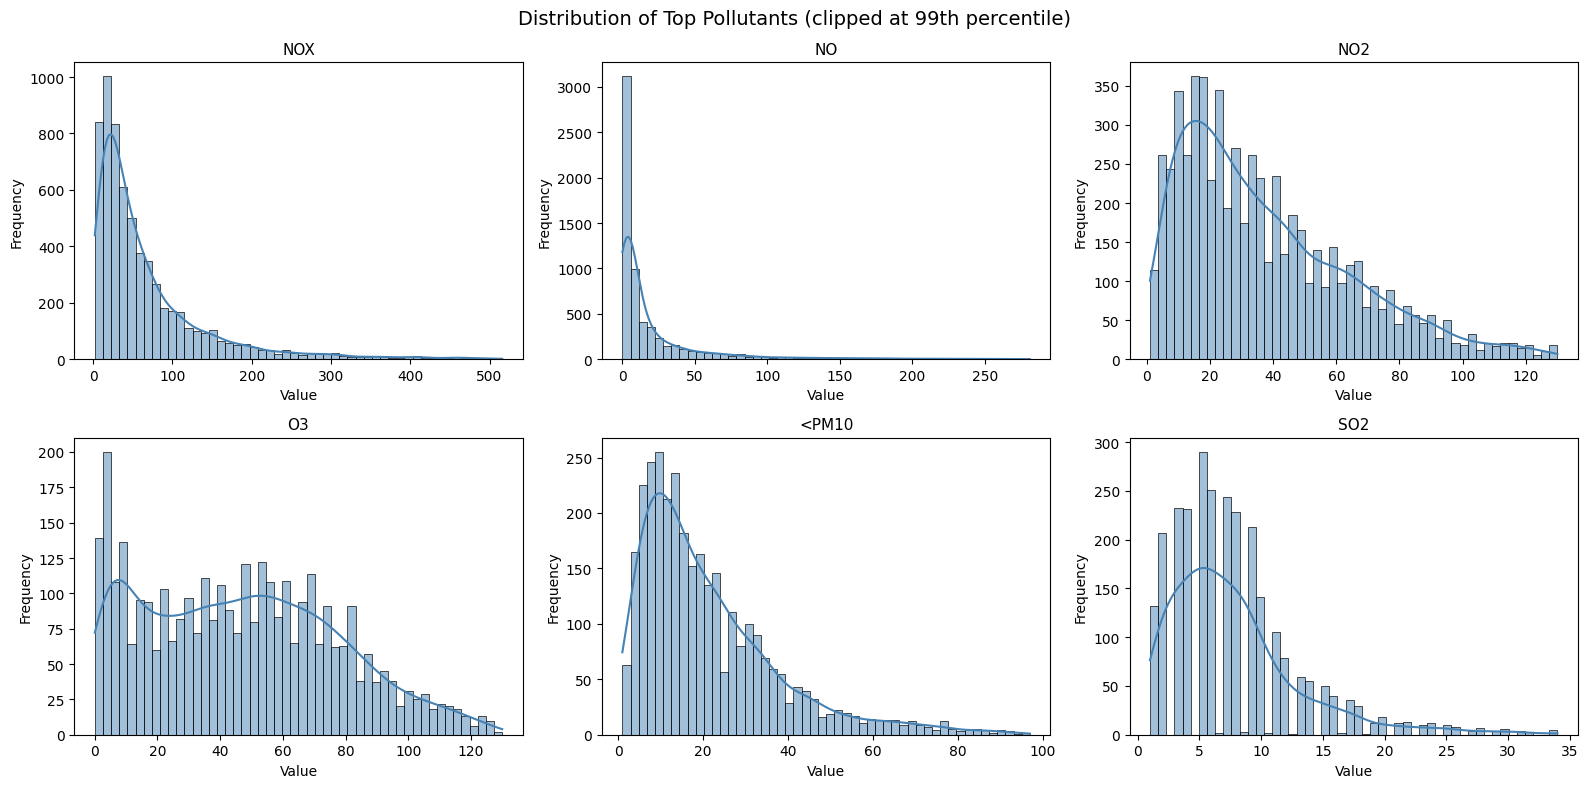

In [31]:
df_top = df_pollutants[df_pollutants["magnitude_name"].isin(top_pollutants)].copy()

n = len(top_pollutants)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for ax, pol in zip(axes, top_pollutants):
    data = df_top[df_top["magnitude_name"] == pol]["value"].dropna()
    cap = data.quantile(0.99)
    sns.histplot(data[data <= cap], ax=ax, kde=True, bins=50, color="steelblue")
    ax.set_title(pol, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Distribution of Top Pollutants (clipped at 99th percentile)", fontsize=14)
plt.tight_layout()
plt.show()

The histograms confirm that most pollutant distributions are strongly right-skewed: the majority of measurements are low, but occasional spikes push the mean well above the median. This is typical of air quality data and justifies using the median as a more robust central tendency measure. The KDE curves reveal whether the distribution is unimodal or has multiple peaks, which could suggest different emission regimes (e.g. weekday vs weekend traffic patterns).

Distribution of meteorological variables. Understanding the shape of temperature, humidity, wind speed and other parameters is important since these will be used as predictors of pollution in later tasks.

In [ ]:
weather_in_data = [w for w in weather if w in df_weather["magnitude_name"].values]
n = len(weather_in_data)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, weather_in_data):
    data = df_weather[df_weather["magnitude_name"] == var]["value"].dropna()
    cap = data.quantile(0.99)
    sns.histplot(data[data <= cap], ax=ax, kde=True, bins=50, color="mediumseagreen")
    ax.set_title(var, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Distribution of Meteorological Variables (clipped at 99th percentile)", fontsize=14)
plt.tight_layout()
plt.show()

Weather variables show more symmetric distributions compared to pollutants. Temperature and solar radiation follow approximately normal distributions reflecting their natural seasonal cycles. Rainfall is strongly right-skewed with many zero or near-zero values and rare heavy precipitation events — this is typical of a semi-arid Mediterranean climate like Madrid's.

Boxplots per station for the top 3 pollutants reveal which monitoring stations have consistently high or highly variable readings. Stations are ordered by median value.

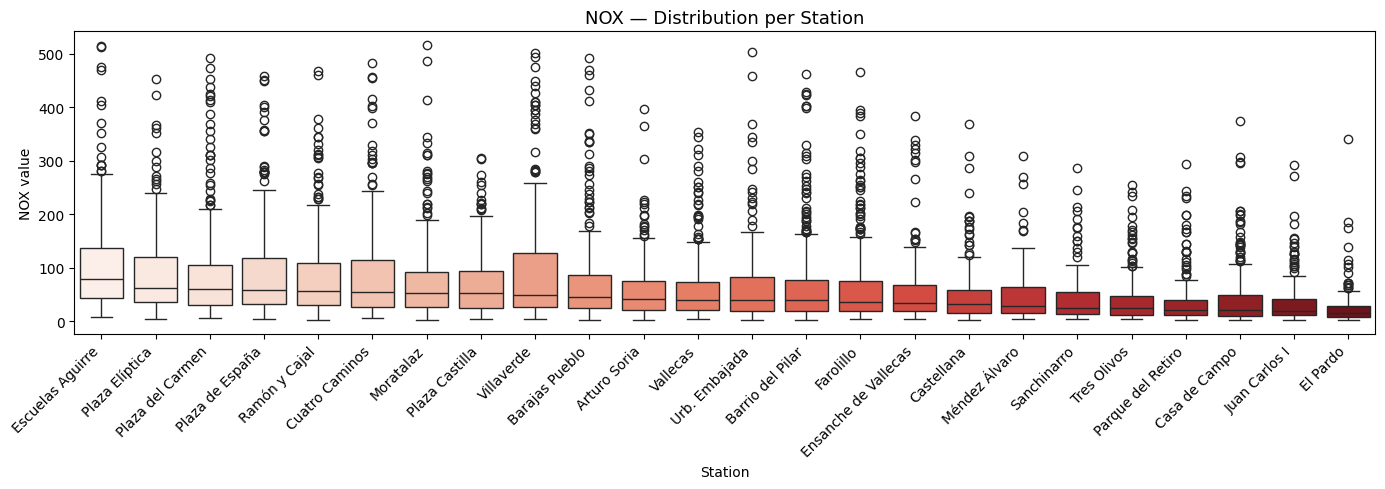

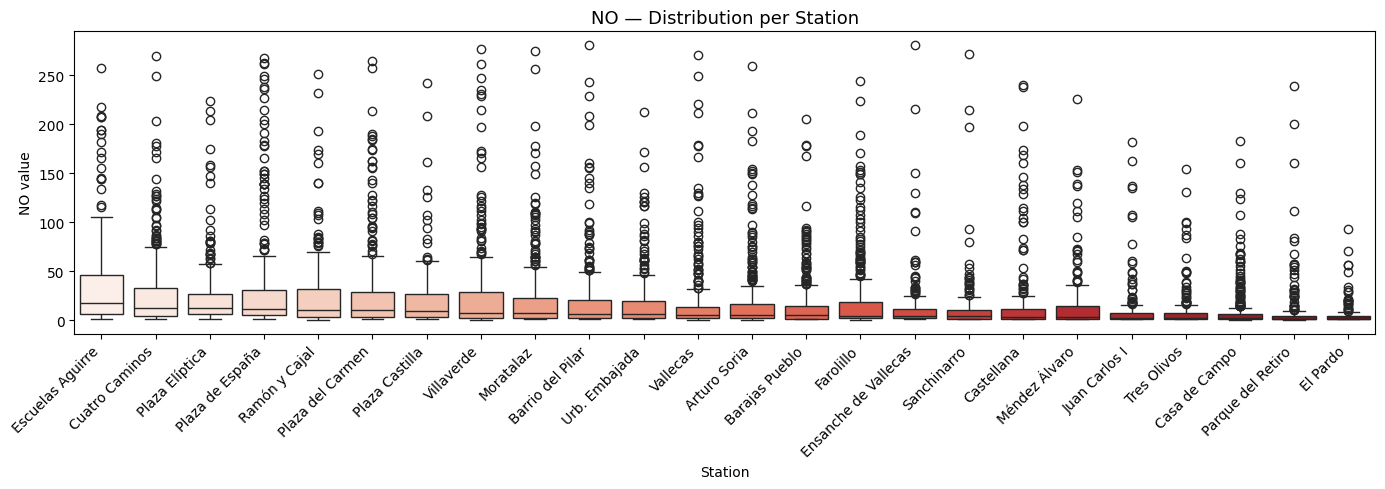

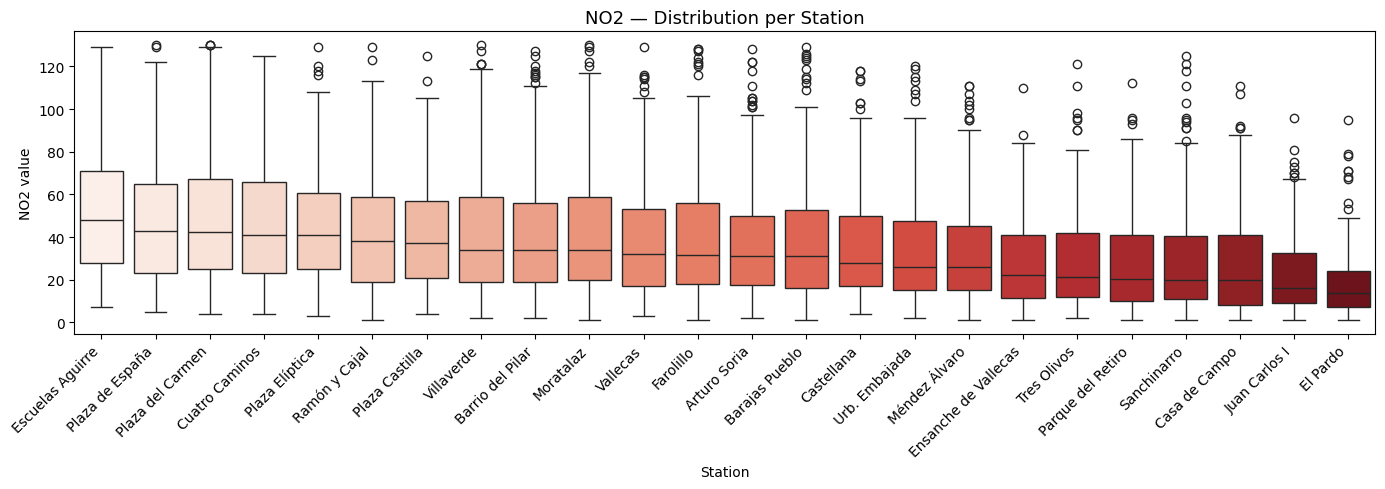

In [32]:
for pol in top_pollutants[:3]:
    data = df_pollutants[df_pollutants["magnitude_name"] == pol].copy()
    cap = data["value"].quantile(0.99)
    data = data[data["value"] <= cap]

    order = (
        data.groupby("sensor_name")["value"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=data, x="sensor_name", y="value",
                order=order, ax=ax, palette="Reds")
    ax.set_title(f"{pol} — Distribution per Station", fontsize=13)
    ax.set_xlabel("Station")
    ax.set_ylabel(f"{pol} value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

What we observe — Boxplots per Station: The boxplots make it clear that pollution levels are not uniform across monitoring stations. Some stations consistently record higher medians, while others show much wider interquartile ranges — indicating more variable conditions. Stations with high variance may be located near sources that operate intermittently (e.g. industrial facilities or busy intersections with varying traffic flow). Stations with consistently high medians are the most concerning from a public health perspective.

#### 1.10) Correlation Between Pollutants

Before closing the EDA, we compute a correlation matrix between the top pollutants. This reveals which pollutants tend to rise and fall together — likely sharing a common source (e.g. traffic emissions) — and which behave independently. This analysis also lays the groundwork for Task 6, where we build a correlation-based sensor network.


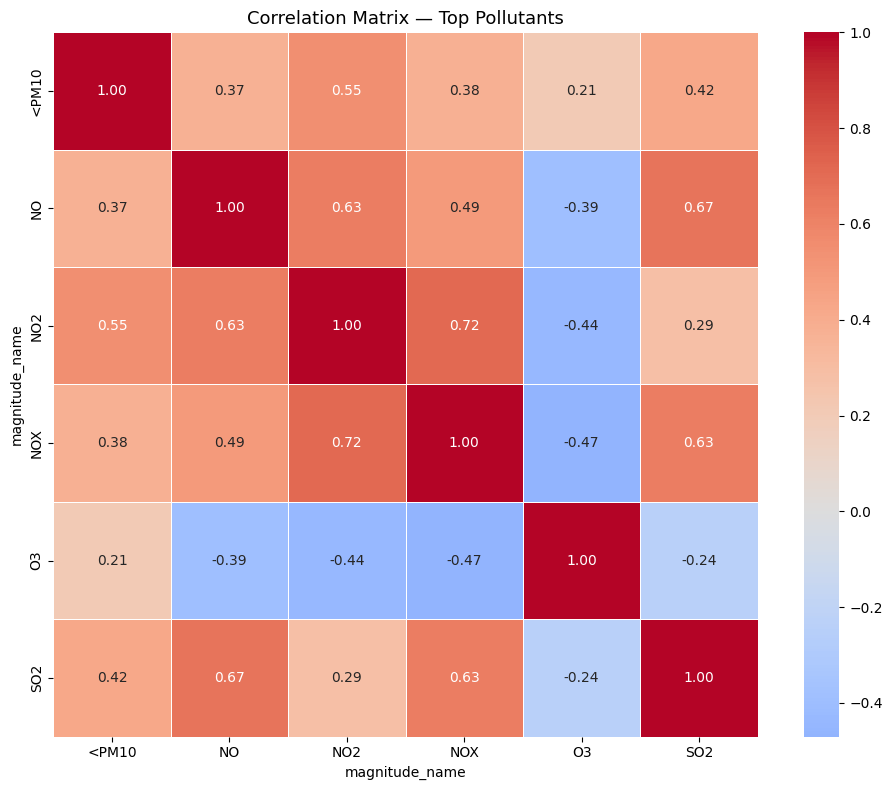

In [33]:
# Pivot to wide format: rows = (date, sensor), columns = pollutant
pollutant_wide = (
    df_pollutants[df_pollutants["magnitude_name"].isin(top_pollutants)]
    .groupby(["entry_date", "magnitude_name"])["value"]
    .mean()
    .unstack("magnitude_name")
)

corr = pollutant_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
    square=True
)
ax.set_title("Correlation Matrix — Top Pollutants", fontsize=13)
plt.tight_layout()
plt.show()

What we observe — Correlation Matrix: NO, NO2 and NOX are expected to show very strong positive correlations (r > 0.9) since they are chemically related: NOX is the sum of NO and NO2, and all three are primarily produced by combustion engines. CO should also correlate positively with this group, as it shares the same traffic emission source. O3 is typically negatively correlated with NO: near traffic sources, NO rapidly destroys ozone through a known photochemical reaction, so high NO tends to coincide with low O3. PM10 and PM2.5 may show moderate correlation with the combustion group but are also influenced by other sources such as road dust and construction, making their relationship less tight. Pollutants that show near-zero correlation with all others may have distinct sources (e.g. BENCENO from fuel evaporation, SO2 from industrial activity) and will behave more independently in the network analysis of Task 6.